# Bequeathed-Runner-Adjusted ERA — 2025 Season

Traditional ERA does not take the luck of bequeathed runners (runners that a starter leaves on base upon exiting) scoring into account. Whether those runners score is
decided by the reliever, yet the runs are charged to the starter.
A starter who hands the bullpen a runner on 2nd with 2 outs gets charged a
full run if the reliever gives up a bloop single, and zero if the reliever
strikes the next guy out. Neither outcome tells us anything about the starter and is entirely determined by a separate player.

This notebook explores several methods to adjust ERA for this. At the moment of the pitching change, replace the actual
downstream outcome of the bequeathed runners with their expected value
under league-average pitching, given the base-out state at handoff.

We compute that expectation two ways, side by side:

| Method | What gets charged | Interpretation |
|---|---|---|
| **A. Marginal run expectancy (RE24-based)** | RE(state, outs) − RE(bases empty, outs) | The marginal run value of the mess left behind (includes knock on effects that aren't directly related to the runners themselves scoring) |
| **B. Per-runner scoring probability** | `Σ P(runner on base b scores \| state, outs)` | For each specific runner standing on base at the handoff, what's the league-average chance he crosses the plate |

And each method uses two sources for the expectation tables:

1. Empirical: Computed from 2025 play-by-play itself
2. Published: Standard historical league-average tables (hardcoded below)

giving four adjusted-ERA variants to compare.

**Data:** pitch-level Statcast data via [`pybaseball`](https://github.com/jldbc/pybaseball),
collapsed to plate-appearance level.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests


from pybaseball import statcast, pitching_stats, playerid_reverse_lookup
from pybaseball import cache

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
SEASON = 2025

## 1. Pull the 2025 season, pitch by pitch

We pull month-by-month and immediately drop to the ~18 columns we need
for memory purposes. We later store the data as a csv for quick reference.

In [ ]:
COLS = [
    "game_pk", "game_date", "game_type", "at_bat_number", "pitch_number",
    "inning", "inning_topbot", "outs_when_up",
    "on_1b", "on_2b", "on_3b", "bat_score", "post_bat_score",
    "pitcher", "batter", "events", "home_team", "away_team",
]

# 2025 regular season: Tokyo Series opened Mar 18, final day Sep 28.
MONTH_CHUNKS = [
    ("2025-03-18", "2025-03-31"),
    ("2025-04-01", "2025-04-30"),
    ("2025-05-01", "2025-05-31"),
    ("2025-06-01", "2025-06-30"),
    ("2025-07-01", "2025-07-31"),
    ("2025-08-01", "2025-08-31"),
    ("2025-09-01", "2025-09-28"),
]

chunks = []
for start, end in MONTH_CHUNKS:
    df = statcast(start_dt=start, end_dt=end)
    if df is not None and len(df):
        chunks.append(df[COLS])

sc = pd.concat(chunks, ignore_index=True)
print(f"{len(sc):,} pitches pulled")
sc.head(3)

In [ ]:
sc.to_csv("statcast_pitches_2025.csv", index=False)

## 2. Collapse to plate-appearance level

For each PA we snapshot the state at PA start (bases, outs, score) from
the first pitch, and the outcome (events, post_bat_score) from the
last pitch. Runs that score mid-PA (wild pitches, steals of home) are
still captured, because we measure runs as the score difference between
consecutive PA-start snapshots.

One standard simplification: RE24 states are evaluated at PA start, so
mid-PA base-state changes (stolen bases, pickoffs) are folded into the
following snapshot rather than treated as their own states.

In [2]:
sc = pd.read_csv("statcast_pitches_2025.csv")

In [3]:
BASE_COLS = [("on_1b", 1), ("on_2b", 2), ("on_3b", 3)]
HALF_KEY = ["game_pk", "inning", "inning_topbot"]

STATE_ORDER = ["---", "1--", "-2-", "--3", "12-", "1-3", "-23", "123"]


def base_state(row) -> str:
    """Encode base occupancy like '1-3' from the on_Xb runner-id columns."""
    return "".join(
        str(b) if pd.notna(row[col]) else "-" for col, b in BASE_COLS
    )


def to_pa_table(sc: pd.DataFrame) -> pd.DataFrame:
    """Collapse pitch-level Statcast data to one row per plate appearance.

    The PA-start snapshot (bases, outs, score) comes from the first pitch;
    the outcome (events, post_bat_score) from the last pitch.
    """
    sc = sc[sc["game_type"] == "R"].copy()
    sc = sc.sort_values(["game_pk", "at_bat_number", "pitch_number"])
    gb = sc.groupby(["game_pk", "at_bat_number"], sort=True)

    first = gb.first()
    last = gb.last()

    keep = [
        "game_date", "inning", "inning_topbot", "outs_when_up",
        "on_1b", "on_2b", "on_3b", "bat_score", "pitcher", "batter",
        "home_team", "away_team",
    ]
    pa = first[keep].copy()
    pa["events"] = last["events"]
    pa["post_bat_score"] = last["post_bat_score"]
    pa = pa.reset_index()
    pa["state"] = pa.apply(base_state, axis=1)
    return pa


def add_runs_rest_of_inning(pa: pd.DataFrame) -> pd.DataFrame:
    """Runs scored from each PA to the end of the half-inning."""
    pa = pa.sort_values(["game_pk", "at_bat_number"]).copy()
    g = pa.groupby(HALF_KEY, sort=False)
    pa["final_bat_score"] = g["post_bat_score"].transform("last")
    pa["runs_roi"] = pa["final_bat_score"] - pa["bat_score"]
    return pa


def empirical_re24(pa: pd.DataFrame, max_inning: int = 8) -> pd.DataFrame:
    """24 base-out state run-expectancy matrix from innings 1..max_inning.

    Innings 9+ are excluded: home 9ths can be truncated (walk-offs) or not
    played, and extras start with an automatic runner. Both bias the table.
    """
    sub = pa[pa["inning"] <= max_inning]
    re = (
        sub.groupby(["state", "outs_when_up"])["runs_roi"]
        .agg(["mean", "size"])
        .reset_index()
    )
    mat = re.pivot(index="state", columns="outs_when_up", values="mean")
    mat = mat.reindex(STATE_ORDER)
    mat.columns = [f"{o} outs" for o in mat.columns]
    return mat


def track_half_inning_scoring(group: pd.DataFrame) -> dict:
    """For one half-inning, return {runner_id: scored_bool}.

    A runner 'disappears' between consecutive PA-start snapshots either by
    scoring or by being put out. The runs scored between snapshots tell us
    how many disappearing players scored. The lead-runner heuristic assigns them, front-runner first.
    Any surplus run belongs to the batter.
    """
    rows = group.to_dict("records")
    scored = {}
    n = len(rows)
    for t, row in enumerate(rows):
        cur = {}
        for col, b in BASE_COLS:
            v = row[col]
            if pd.notna(v):
                cur[int(v)] = b
        if t < n - 1:
            nxt_row = rows[t + 1]
            nxt = {
                int(nxt_row[col])
                for col, _ in BASE_COLS
                if pd.notna(nxt_row[col])
            }
            runs = int(nxt_row["bat_score"] - row["bat_score"])
        else:
            nxt = set()
            runs = int(row["post_bat_score"] - row["bat_score"])
        if row.get("events") == "home_run" and runs > 0:
            runs -= 1  # one run belongs to the batter, not a baserunner
        gone = sorted(
            (rid for rid in cur if rid not in nxt),
            key=lambda rid: -cur[rid],  # lead runner first (3B, 2B, 1B)
        )
        for rid in gone:
            if rid not in scored:  # first disappearance decides
                scored[rid] = runs > 0
            if runs > 0:
                runs -= 1
    return scored


def build_scoring_map(pa: pd.DataFrame) -> dict:
    """{half_inning_key_tuple: {runner_id: scored}} for the whole dataset."""
    out = {}
    for key, grp in pa.sort_values("at_bat_number").groupby(HALF_KEY, sort=False):
        out[key] = track_half_inning_scoring(grp)
    return out


def empirical_scoring_prob(
    pa: pd.DataFrame, scoring_map: dict, max_inning: int = 8
):
    """P(runner scores | base, outs) and P(runner scores | base, outs, state).

    Returns (pooled_df, full_state_df) with columns n and p.
    """
    recs = []
    sub = pa[pa["inning"] <= max_inning]
    for key, grp in sub.sort_values("at_bat_number").groupby(HALF_KEY, sort=False):
        smap = scoring_map.get(key, {})
        for row in grp.to_dict("records"):
            for col, b in BASE_COLS:
                v = row[col]
                if pd.notna(v):
                    rid = int(v)
                    recs.append(
                        {
                            "base": b,
                            "outs": int(row["outs_when_up"]),
                            "state": row["state"],
                            "scored": bool(smap.get(rid, False)),
                        }
                    )
    obs = pd.DataFrame(recs)
    pooled = (
        obs.groupby(["base", "outs"])["scored"].agg(n="size", p="mean").reset_index()
    )
    full = (
        obs.groupby(["base", "outs", "state"])["scored"]
        .agg(n="size", p="mean")
        .reset_index()
    )
    return pooled, full


def find_starter_handoffs(pa: pd.DataFrame) -> pd.DataFrame:
    """Find every mid-inning pitching change where the starter leaves
    runners on base. One row per handoff with the state, outs, and the
    bequeathed runner ids by base."""
    pa = pa.sort_values(["game_pk", "at_bat_number"]).copy()

    # Starter for each defensive side = pitcher of that side's first PA.
    starters = (
        pa.groupby(["game_pk", "inning_topbot"], sort=False)["pitcher"]
        .first()
        .rename("starter_id")
    )
    pa = pa.join(starters, on=["game_pk", "inning_topbot"])

    events = []
    for key, grp in pa.groupby(HALF_KEY, sort=False):
        rows = grp.to_dict("records")
        prev = rows[0]["pitcher"]
        for row in rows:
            if row["pitcher"] != prev:
                if prev == row["starter_id"]:
                    runners = {
                        b: int(row[col])
                        for col, b in BASE_COLS
                        if pd.notna(row[col])
                    }
                    if runners:
                        events.append(
                            {
                                "game_pk": key[0],
                                "inning": key[1],
                                "inning_topbot": key[2],
                                "starter_id": int(prev),
                                "outs": int(row["outs_when_up"]),
                                "state": row["state"],
                                "runners": runners,
                            }
                        )
                prev = row["pitcher"]
    return pd.DataFrame(events)


def actual_bequeathed_runs(handoffs: pd.DataFrame, scoring_map: dict) -> pd.Series:
    """How many bequeathed runners actually scored, per handoff."""
    vals = []
    for row in handoffs.to_dict("records"):
        key = (row["game_pk"], row["inning"], row["inning_topbot"])
        smap = scoring_map.get(key, {})
        vals.append(sum(bool(smap.get(rid, False)) for rid in row["runners"].values()))
    return pd.Series(vals, index=handoffs.index, name="actual_bq_runs")


In [4]:
pa = to_pa_table(sc)
pa = add_runs_rest_of_inning(pa)
print(f"{len(pa):,} plate appearances, "
      f"{pa.groupby(HALF_KEY).ngroups:,} half-innings")
pa.head(3)

183,362 plate appearances, 43,220 half-innings


,game_pk,at_bat_number,game_date,inning,inning_topbot,outs_when_up,on_1b,on_2b,on_3b,bat_score,pitcher,batter,home_team,away_team,events,post_bat_score,state,final_bat_score,runs_roi
0,776135,1,2025-09-28,1,Top,0,NaN,NaN,NaN,0,691951,805904,LAA,HOU,strikeout,0,---,1,1
1,776135,2,2025-09-28,1,Top,1,NaN,NaN,NaN,0,691951,643289,LAA,HOU,single,0,---,1,1
2,776135,3,2025-09-28,1,Top,1,"643,289.000",NaN,NaN,0,691951,605170,LAA,HOU,hit_by_pitch,0,1--,1,1


## 3. The run-expectancy matrix (RE24), empirical vs published

RE(state, outs) = average runs scored from that base-out state to the end
of the half-inning. Two exclusions:

- innings 9+ — home 9ths can be truncated by walk-offs (or not played
  at all), and extra innings start with the automatic runner which both distort
  the averages. We estimate from innings 1–8 only (small impact as starters rarely go into the 9th regardless).
- postseason/exhibition games (already filtered to game_type == 'R').

The published table below is the widely cited 2010–2015 league-average
matrix (values approximate, courtesy of [retrosheet](https://www.tangotiger.net/re24.html)). The 2025 empirical table will differ a bit
with the run environment.

In [5]:
re_emp = empirical_re24(pa)

RE_PUBLISHED = pd.DataFrame(
    {
        "0 outs": [0.481, 0.859, 1.100, 1.361, 1.437, 1.784, 1.964, 2.292],
        "1 outs": [0.254, 0.509, 0.664, 0.950, 0.884, 1.130, 1.376, 1.541],
        "2 outs": [0.098, 0.224, 0.319, 0.353, 0.429, 0.478, 0.580, 0.752],
    },
    index=STATE_ORDER,
)
RE_PUBLISHED.index.name = "state"

comparison = pd.concat(
    {"2025 empirical": re_emp, "published (2010-15)": RE_PUBLISHED,
     "difference": re_emp - RE_PUBLISHED},
    axis=1,
)
comparison

2025 empirical               published (2010-15)                \
              0 outs 1 outs 2 outs              0 outs 1 outs 2 outs   
state                                                                  
---            0.501  0.268  0.105               0.481  0.254  0.098   
1--            0.871  0.508  0.222               0.859  0.509  0.224   
-2-            1.141  0.659  0.330               1.100  0.664  0.319   
--3            1.253  0.902  0.340               1.361  0.950  0.353   
12-            1.521  0.892  0.434               1.437  0.884  0.429   
1-3            1.825  1.208  0.460               1.784  1.130  0.478   
-23            1.971  1.359  0.590               1.964  1.376  0.580   
123            2.369  1.567  0.700               2.292  1.541  0.752   

      difference                
          0 outs 1 outs 2 outs  
state                           
---        0.020  0.014  0.007  
1--        0.012 -0.001 -0.002  
-2-        0.041 -0.005  0.011  
--3       -0.108 -0.048 -0.013  
12-        0.084  0.008  0.005  
1-3        0.041  0.078 -0.018  
-23        0.007 -0.017  0.010  
123        0.077  0.026 -0.052

## 4. Per-runner scoring probabilities

For Method B we need `P(a runner on base b eventually scores | state, outs)`.
Statcast doesn't record who scored on each play, but it does record runner
identities on each base at every pitch. So we track each runner ID through
the half-inning:

- a runner who disappears between consecutive PA snapshots either
  scored or was put out;
- the score change over that window says how many of the disappearing
  players scored
- on a home run one run is deducted for the batter before assignment
  (this also correctly handles a caught-stealing and a homer inside the
  same PA).

Known limitations, all rare and roughly ERA-neutral: pinch-runner
substitutions break the ID chain (the original runner reads as "out"), and
a non-HR play where a trail runner scores while the lead runner is thrown
out is mis-assigned. Both are a small fraction of a percent of runner-PAs.

We estimate the probability two ways: **pooled** by (base, outs) — robust,
9 cells — and **full-state** by (base, outs, state), which captures force
situations, falling back to pooled when a cell has under 200 observations.

In [6]:
scoring_map = build_scoring_map(pa)
sp_pooled, sp_full = empirical_scoring_prob(pa, scoring_map)

sp_pooled_wide = sp_pooled.pivot(index="base", columns="outs", values="p")
sp_pooled_wide.index = [f"runner on {b}B" for b in sp_pooled_wide.index]
sp_pooled_wide.columns = [f"{o} outs" for o in sp_pooled_wide.columns]

# Approximate historical league averages, for comparison
SP_PUBLISHED = {
    (1, 0): 0.39, (1, 1): 0.28, (1, 2): 0.13,
    (2, 0): 0.62, (2, 1): 0.41, (2, 2): 0.21,
    (3, 0): 0.85, (3, 1): 0.66, (3, 2): 0.27,
}
sp_pub_wide = pd.DataFrame(
    {f"{o} outs": [SP_PUBLISHED[(b, o)] for b in (1, 2, 3)] for o in (0, 1, 2)},
    index=[f"runner on {b}B" for b in (1, 2, 3)],
)

pd.concat({"2025 empirical (pooled)": sp_pooled_wide,
           "published (approx.)": sp_pub_wide,
           "difference": sp_pooled_wide - sp_pub_wide}, axis=1)

2025 empirical (pooled)               published (approx.)         \
                              0 outs 1 outs 2 outs              0 outs 1 outs   
runner on 1B                   0.387  0.257  0.128               0.390  0.280   
runner on 2B                   0.606  0.410  0.228               0.620  0.410   
runner on 3B                   0.827  0.659  0.271               0.850  0.660   

                    difference                
             2 outs     0 outs 1 outs 2 outs  
runner on 1B  0.130     -0.003 -0.023 -0.002  
runner on 2B  0.210     -0.014 -0.000  0.018  
runner on 3B  0.270     -0.023 -0.001  0.001

## 5. Find every handoff where a starter bequeathed runners

A handoff = the first mid-inning pitching change in a half-inning where the
outgoing pitcher is that game's starter (the pitcher of the defensive
side's first PA) and there is at least one runner on base at the incoming
reliever's first PA. Everyone on base at that moment was put there by the
starter (if earned), so under official scoring any of them who scores is charged to him.

In [8]:
handoffs = find_starter_handoffs(pa)
handoffs["actual_bq_runs"] = actual_bequeathed_runs(handoffs, scoring_map)
handoffs["n_runners"] = handoffs["runners"].apply(len)

print(f"{len(handoffs):,} starter handoffs with runners on base")
print(f"{handoffs['n_runners'].sum():,} bequeathed runners, "
      f"{handoffs['actual_bq_runs'].sum():,} of whom scored "
      f"({handoffs['actual_bq_runs'].sum() / handoffs['n_runners'].sum():.1%})")

handoffs.groupby(["state", "outs"]).size().rename("count").reset_index() \
        .pivot(index="state", columns="outs", values="count") \
        .reindex(STATE_ORDER).fillna(0).astype(int)

1,687 starter handoffs with runners on base
2,732 bequeathed runners, 896 of whom scored (32.8%)


outs,0,1,2
state,,,
---,0,0,0
1--,105,198,234
-2-,33,81,115
--3,5,25,40
12-,85,146,153
1-3,24,55,81
-23,28,44,41
123,36,74,84


## 6. Expected charges: four variants per handoff

For each handoff we compute the expected bequeathed-runner runs under:

- **`exp_re_emp`** — marginal RE, 2025 empirical matrix
- **`exp_re_pub`** — marginal RE, published matrix
- **`exp_sp_emp`** — Σ scoring probabilities, 2025 empirical (full-state
  with pooled fallback)
- **`exp_sp_pub`** — Σ scoring probabilities, published

In [9]:
def marginal_re_charge(re_mat, state, outs):
    col = f"{outs} outs"
    return float(re_mat.loc[state, col] - re_mat.loc["---", col])


SP_FULL_LOOKUP = {
    (r.base, r.outs, r.state): (r.p, r.n) for r in sp_full.itertuples()
}
SP_POOLED_LOOKUP = {(r.base, r.outs): r.p for r in sp_pooled.itertuples()}


def sp_charge_empirical(state, outs, min_n=200):
    total = 0.0
    for b in (1, 2, 3):
        if str(b) in state:
            p_n = SP_FULL_LOOKUP.get((b, outs, state))
            if p_n is not None and p_n[1] >= min_n:
                total += p_n[0]
            else:
                total += SP_POOLED_LOOKUP[(b, outs)]
    return total


def sp_charge_published(state, outs):
    return sum(SP_PUBLISHED[(b, outs)] for b in (1, 2, 3) if str(b) in state)


handoffs["exp_re_emp"] = [
    marginal_re_charge(re_emp, s, o) for s, o in zip(handoffs["state"], handoffs["outs"])
]
handoffs["exp_re_pub"] = [
    marginal_re_charge(RE_PUBLISHED, s, o) for s, o in zip(handoffs["state"], handoffs["outs"])
]
handoffs["exp_sp_emp"] = [
    sp_charge_empirical(s, o) for s, o in zip(handoffs["state"], handoffs["outs"])
]
handoffs["exp_sp_pub"] = [
    sp_charge_published(s, o) for s, o in zip(handoffs["state"], handoffs["outs"])
]

EXP_COLS = ["exp_re_emp", "exp_re_pub", "exp_sp_emp", "exp_sp_pub"]
handoffs[["state", "outs", "n_runners", "actual_bq_runs"] + EXP_COLS].describe()

,outs,n_runners,actual_bq_runs,exp_re_emp,exp_re_pub,exp_sp_emp,exp_sp_pub
count,"1,687.000","1,687.000","1,687.000","1,687.000","1,687.000","1,687.000","1,687.000"
mean,1.256,1.619,0.531,0.524,0.528,0.543,0.542
std,0.752,0.683,0.786,0.406,0.394,0.417,0.401
min,0.000,1.000,0.000,0.117,0.126,0.119,0.130
25%,1.000,1.000,0.000,0.240,0.255,0.242,0.280
50%,1.000,2.000,0.000,0.370,0.378,0.375,0.390
75%,2.000,2.000,1.000,0.623,0.654,0.679,0.690
max,2.000,3.000,3.000,1.869,1.811,1.914,1.860


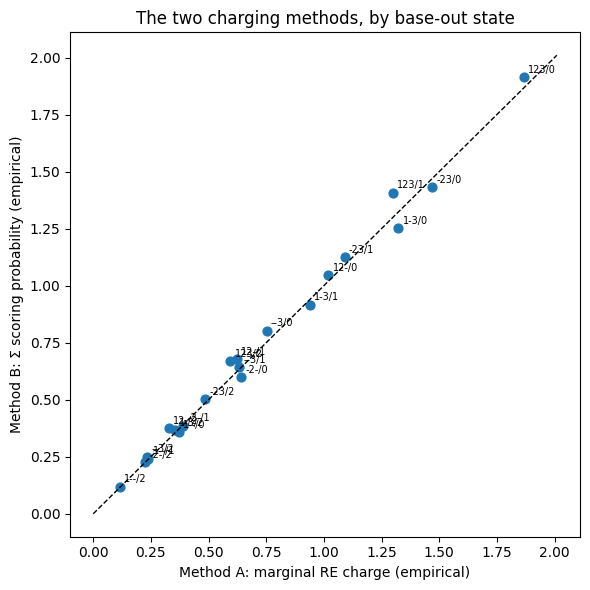

In [10]:
# How do the two methods relate across the states that actually occur
by_state = handoffs.groupby(["state", "outs"])[EXP_COLS].first().reset_index()
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(by_state["exp_re_emp"], by_state["exp_sp_emp"], s=40)
for r in by_state.itertuples():
    ax.annotate(f"{r.state}/{r.outs}", (r.exp_re_emp, r.exp_sp_emp),
                fontsize=7, xytext=(3, 3), textcoords="offset points")
lim = [0, by_state[["exp_re_emp", "exp_sp_emp"]].max().max() * 1.05]
ax.plot(lim, lim, "k--", lw=1)
ax.set_xlabel("Method A: marginal RE charge (empirical)")
ax.set_ylabel("Method B: Σ scoring probability (empirical)")
ax.set_title("The two charging methods, by base-out state")
plt.tight_layout()
plt.show()

## 7. Adjusted ERA

Per starter, over the season:

$$\text{adjERA} = 9 \times \frac{ER - \text{actual bequeathed runs} + \text{expected bequeathed runs}}{IP}$$

A pitcher whose bequeathed runners scored more often than the state-average
(bad bullpen support / bad luck) sees his ERA come down, one who was
bailed out sees it go up.

One honest caveat: Statcast has no earned/unearned flag, so we treat all
bequeathed-runner runs as earned. The large majority are (unearned runs
require an error in the chain), but to be exact about it we also compute
**adjRA9** using total runs allowed.

In [11]:
# Aggregate handoff ledger per starter
ledger = (
    handoffs.groupby("starter_id")
    .agg(
        handoffs=("state", "size"),
        bq_runners=("n_runners", "sum"),
        actual_bq=("actual_bq_runs", "sum"),
        exp_re_emp=("exp_re_emp", "sum"),
        exp_re_pub=("exp_re_pub", "sum"),
        exp_sp_emp=("exp_sp_emp", "sum"),
        exp_sp_pub=("exp_sp_pub", "sum"),
    )
    .reset_index()
)

# Official season stats straight from the MLB Stats API.
def mlb_season_pitching(season, game_type="R"):
    url = "https://statsapi.mlb.com/api/v1/stats"
    rows, offset, limit = [], 0, 500
    while True:
        params = {
            "stats": "season", "group": "pitching", "season": season,
            "gameType": game_type, "playerPool": "ALL",
            "limit": limit, "offset": offset,
        }
        r = requests.get(url, params=params, timeout=30)
        r.raise_for_status()
        stats_blocks = r.json().get("stats", [])
        splits = stats_blocks[0].get("splits", []) if stats_blocks else []
        for s in splits:
            st = s["stat"]
            rows.append({
                "mlbam_id": s["player"]["id"],
                "Name": s["player"]["fullName"],
                "Team": s.get("team", {}).get("name", ""),
                "GS": int(st.get("gamesStarted", 0)),
                "IP": float(st.get("inningsPitched", 0.0)),
                "ER": int(st.get("earnedRuns", 0)),
                "R": int(st.get("runs", 0)),
                "ERA": float(st["era"]) if st.get("era") not in (None, "-", "-.--") else np.nan,
            })
        if len(splits) < limit:
            break
        offset += limit
    return pd.DataFrame(rows)


def ip_to_float(ip):
    """MLB/FanGraphs IP like 150.1 means 150 and 1/3 innings."""
    whole = np.floor(ip)
    return whole + (ip - whole) * 10 / 3


MIN_IP = 80

stats = mlb_season_pitching(SEASON)
stats["ip_f"] = ip_to_float(stats["IP"])
stats = stats[(stats["GS"] >= 10) & (stats["ip_f"] >= MIN_IP)]

df = stats.merge(ledger, left_on="mlbam_id", right_on="starter_id", how="left")
for c in ["handoffs", "bq_runners", "actual_bq"] + EXP_COLS:
    df[c] = df[c].fillna(0)

for c in EXP_COLS:
    tag = c.replace("exp_", "")
    df[f"adjERA_{tag}"] = 9 * (df["ER"] - df["actual_bq"] + df[c]) / df["ip_f"]
df["adjRA9_sp_emp"] = 9 * (df["R"] - df["actual_bq"] + df["exp_sp_emp"]) / df["ip_f"]
df["RA9"] = 9 * df["R"] / df["ip_f"]

# delta > 0  ->  official ERA flattered the pitcher (relievers stranded his mess)
df["delta"] = df["adjERA_sp_emp"] - df["ERA"]
df["delta_pct"] = df["delta"] / df["ERA"]

ADJ_COLS = [f"adjERA_{c.replace('exp_', '')}" for c in EXP_COLS]
df[ADJ_COLS].corr(numeric_only=True).round(4)

,adjERA_re_emp,adjERA_re_pub,adjERA_sp_emp,adjERA_sp_pub
adjERA_re_emp,1.000,1.000,1.000,1.000
adjERA_re_pub,1.000,1.000,1.000,1.000
adjERA_sp_emp,1.000,1.000,1.000,1.000
adjERA_sp_pub,1.000,1.000,1.000,1.000


In [12]:
# Most UNLUCKY starters: bequeathed runners scored far more than expected, so their official ERA overstates the damage
show = ["Name", "Team", "IP", "bq_runners", "actual_bq", "exp_sp_emp",
        "ERA", "adjERA_sp_emp", "adjERA_re_emp", "adjERA_sp_pub",
        "adjERA_re_pub", "delta", "delta_pct"]
df.sort_values("delta").head(15)[show].reset_index(drop=True)

,Name,Team,IP,bq_runners,actual_bq,exp_sp_emp,ERA,adjERA_sp_emp,adjERA_re_emp,adjERA_sp_pub,adjERA_re_pub,delta,delta_pct
0,Trevor Williams,Washington Nationals,82.200,19,11,7.601,6.210,5.836,5.813,5.825,5.806,-0.374,-0.060
1,Taj Bradley,Minnesota Twins,142.200,19,12,7.232,5.050,4.746,4.734,4.743,4.733,-0.304,-0.060
2,Eury Pérez,Miami Marlins,95.100,10,7,3.841,4.250,3.950,3.936,3.952,3.937,-0.300,-0.071
3,Michael Wacha,Kansas City Royals,172.200,20,11,5.406,3.860,3.566,3.550,3.568,3.556,-0.294,-0.076
4,Michael Soroka,Chicago Cubs,89.200,12,8,5.136,4.520,4.229,4.228,4.225,4.217,-0.291,-0.064
5,Aaron Civale,Chicago Cubs,102.000,6,5,1.813,4.850,4.572,4.573,4.577,4.573,-0.278,-0.057
6,Davis Martin,Chicago White Sox,142.200,16,11,6.766,4.100,3.833,3.828,3.835,3.826,-0.267,-0.065
7,Dustin May,Boston Red Sox,132.100,10,6,2.571,4.960,4.731,4.720,4.734,4.723,-0.229,-0.046
8,Shane Baz,Tampa Bay Rays,166.100,22,11,7.244,4.870,4.667,4.642,4.663,4.646,-0.203,-0.042
9,Jacob Lopez,Athletics,92.200,10,5,3.142,4.080,3.899,3.880,3.898,3.878,-0.181,-0.044


In [13]:
# Most FLATTERED starters: the bullpen stranded their runners
df.sort_values("delta", ascending=False).head(15)[show].reset_index(drop=True)

,Name,Team,IP,bq_runners,actual_bq,exp_sp_emp,ERA,adjERA_sp_emp,adjERA_re_emp,adjERA_sp_pub,adjERA_re_pub,delta,delta_pct
0,Tomoyuki Sugano,Baltimore Orioles,157.000,21,2,6.891,4.640,4.924,4.910,4.926,4.924,0.284,0.061
1,Patrick Corbin,Texas Rangers,155.100,27,6,10.655,4.400,4.673,4.660,4.684,4.667,0.273,0.062
2,Andrew Heaney,Los Angeles Dodgers,122.100,15,1,4.737,5.520,5.793,5.779,5.783,5.787,0.273,0.049
3,Merrill Kelly,Texas Rangers,184.000,22,3,8.533,3.520,3.792,3.787,3.790,3.786,0.272,0.077
4,Casey Mize,Detroit Tigers,149.000,19,2,6.238,3.870,4.122,4.109,4.123,4.121,0.252,0.065
5,Seth Lugo,Kansas City Royals,145.100,19,1,4.453,4.150,4.363,4.343,4.358,4.353,0.213,0.051
6,Bailey Ober,Minnesota Twins,146.100,15,1,4.314,5.100,5.309,5.304,5.307,5.309,0.209,0.041
7,Quinn Priester,Milwaukee Brewers,157.100,19,4,7.611,3.320,3.524,3.518,3.523,3.515,0.204,0.062
8,Nick Lodolo,Cincinnati Reds,156.200,16,1,4.507,3.330,3.533,3.517,3.528,3.529,0.203,0.061
9,Jeffrey Springs,Athletics,171.000,10,0,3.408,4.110,4.285,4.286,4.293,4.290,0.175,0.042


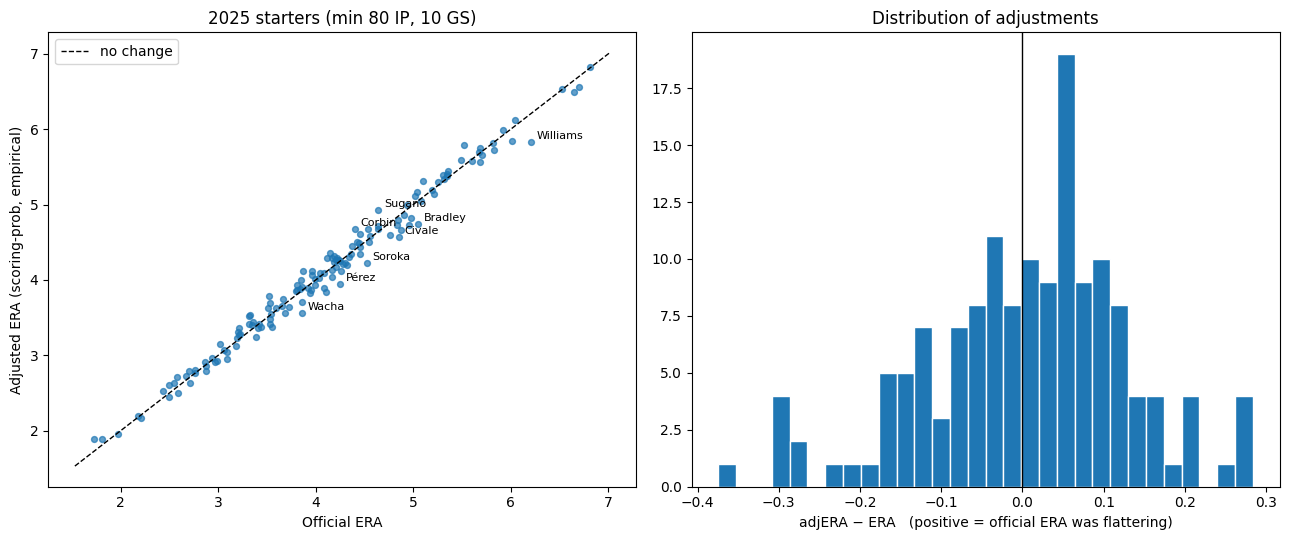

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
ax.scatter(df["ERA"], df["adjERA_sp_emp"], s=18, alpha=0.7)
lim = [df["ERA"].min() - 0.2, df["ERA"].max() + 0.2]
ax.plot(lim, lim, "k--", lw=1, label="no change")
biggest = df.reindex(df["delta"].abs().sort_values(ascending=False).index).head(8)
for r in biggest.itertuples():
    ax.annotate(r.Name.split()[-1], (r.ERA, r.adjERA_sp_emp),
                fontsize=8, xytext=(4, 2), textcoords="offset points")
ax.set_xlabel("Official ERA")
ax.set_ylabel("Adjusted ERA (scoring-prob, empirical)")
ax.set_title(f"{SEASON} starters (min {MIN_IP} IP, 10 GS)")
ax.legend()

ax = axes[1]
ax.hist(df["delta"], bins=30, edgecolor="white")
ax.axvline(0, color="k", lw=1)
ax.set_xlabel("adjERA − ERA   (positive = official ERA was flattering)")
ax.set_title("Distribution of adjustments")

plt.tight_layout()
plt.show()

In [15]:
# How much do the four variants disagree for any single pitcher?
spread = df[ADJ_COLS].max(axis=1) - df[ADJ_COLS].min(axis=1)
print(f"Median spread across the four variants: {spread.median():.3f} runs of ERA")
print(f"Max spread: {spread.max():.3f}")

#Ouput result csv for further exploration
df.to_csv(f"adjusted_era_{SEASON}.csv", index=False)

Median spread across the four variants: 0.014 runs of ERA
Max spread: 0.046


## 8. Caveats & extensions

**Methodological notes**

- **Earned vs unearned:** Statcast lacks earned-run flags; `adjERA` assumes
  bequeathed-runner runs are earned. `adjRA9_sp_emp` sidesteps this entirely.
- **Swingmen:** ERA covers all of a pitcher's innings, but we only detect
  handoffs in games he started. For pure starters this is exact; for
  swingmen the relief innings are unadjusted.
- **Runner-tracking edge cases:** pinch-runner substitutions and
  lead-runner-out-while-trail-runner-scores plays are mis-assigned
  (both rare, both roughly unbiased).

**Interesting extensions**

- Charge the starter at the moment of each baserunner event rather than
  at handoff (full RE24 pitching lines).
- Condition scoring probabilities on reliever quality to separate
  "bad luck" from "bad bullpen".
- Multi-season stability: does `delta` persist year-to-year (a repeatable
  skill/usage effect) or regress to zero (pure luck)?